# Experiment: Pulse DDM Net-Click Psychometric Explorer

Objective:
- Interactively test pulse-DDM parameter settings.
- Regroup trials by full-window net click count `#R - #L`.
- Plot hit-conditioned `P(choose right | hit)` against `#R - #L`.
- Inspect the per-bin miss fraction at the same time.

Editable knobs:
- `LAMBDA_RIGHT`, `LAMBDA_LEFT`
- `NOISE_SCALE`, `LAMBDA_COMMIT`, `DELTA_CLICK_X`
- `DUR`, `DT_DDM`, `NUM_TRIALS_PER_CONDITION`

Notes:
- The notebook mirrors the current behavior-model implementation in `rate_model_core.accumulator_simulation`.
- `#R - #L` is counted over the full stimulus window, not only until boundary hit.
- The plotted psychometric curve uses only boundary-hit trials in each net-click bin.


## Run Order

1. Edit the parameter cell.
2. Run the helper-function cell.
3. Run the simulation cell.
4. Optionally run the save cell.


In [1]:
from __future__ import annotations

import csv
import json
import runpy
from pathlib import Path

_NOTEBOOK_SETUP = None
for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    helper = candidate / 'figures_code' / 'notebook_setup.py'
    if helper.exists():
        _NOTEBOOK_SETUP = runpy.run_path(str(helper))
        break
if _NOTEBOOK_SETUP is None:
    raise RuntimeError('Could not locate figures_code/notebook_setup.py')

REPO_ROOT = _NOTEBOOK_SETUP['REPO_ROOT']

import matplotlib.pyplot as plt
import numpy as np

from rate_model_core.accumulator_simulation import PulseDDMConfig, simulate_ddm_trials


In [2]:


SAVE_OUTPUTS = False
OUTPUT_DIR = REPO_ROOT / 'results' / 'pddm_net_click_notebook'
RUN_SLUG = 'interactive_run'


In [3]:
def fixed_conditions(*, lambda_right: float, lambda_left: float) -> list[dict[str, float | str]]:
    return [
        {
            'condition': 'right_biased',
            'lambda_click_L': float(lambda_left),
            'lambda_click_R': float(lambda_right),
        },
        {
            'condition': 'left_biased',
            'lambda_click_L': float(lambda_right),
            'lambda_click_R': float(lambda_left),
        },
    ]


def binomial_half_width(p_right: float, num_hit: int) -> float:
    if int(num_hit) <= 0 or not np.isfinite(float(p_right)):
        return float('nan')
    return 1.96 * np.sqrt(float(p_right) * (1.0 - float(p_right)) / float(num_hit))


def simulate_condition(*, condition: dict[str, float | str], num_trials: int, dt_ddm: float, t_start: int, dur: int, x0: float, boundary: float, noise_scale: float, lambda_commit: float, delta_click_x: float, seed: int):
    return simulate_ddm_trials(
        decision_mode='discrete',
        config=PulseDDMConfig(
            lambda_click_L=float(condition['lambda_click_L']),
            lambda_click_R=float(condition['lambda_click_R']),
            delta_click_x=float(delta_click_x),
            noise_scale=float(noise_scale),
            lambda_commit=float(lambda_commit),
        ),
        dt_DDM=float(dt_ddm),
        dur=int(dur),
        t_start=int(t_start),
        x0=float(x0),
        boundary=float(boundary),
        num_trials=int(num_trials),
        seed=int(seed),
        return_traj=False,
    )


def aggregate_by_net_click(results: list[tuple[str, object]]) -> list[dict[str, float | int]]:
    pooled_net_clicks = []
    pooled_choices = []
    pooled_hit_boundary = []

    for _, result in results:
        pooled_net_clicks.append(np.asarray(result.metadata['net_click_count'], dtype=int))
        pooled_choices.append((np.asarray(result.choice) == 1).astype(float))
        pooled_hit_boundary.append(np.asarray(result.hit_boundary, dtype=bool))

    net_clicks = np.concatenate(pooled_net_clicks, axis=0)
    choices = np.concatenate(pooled_choices, axis=0)
    hit_boundary = np.concatenate(pooled_hit_boundary, axis=0)

    rows = []
    for value in np.unique(net_clicks):
        mask = net_clicks == int(value)
        hit_mask = mask & hit_boundary
        num_trials = int(np.sum(mask))
        num_hit = int(np.sum(hit_mask))
        p_right = float(np.mean(choices[hit_mask])) if num_hit > 0 else float('nan')
        miss_fraction = 1.0 - (float(num_hit) / float(num_trials))
        rows.append(
            {
                'net_click_count': int(value),
                'num_trials': num_trials,
                'num_hit': num_hit,
                'miss_fraction': miss_fraction,
                'p_right': p_right,
                'ci_half_width': binomial_half_width(p_right, num_hit),
            }
        )
    return rows


def run_experiment():
    conditions = fixed_conditions(lambda_right=LAMBDA_RIGHT, lambda_left=LAMBDA_LEFT)
    seed_sequence = np.random.SeedSequence(int(SEED))
    child_sequences = seed_sequence.spawn(len(conditions))

    results = []
    condition_rows = []
    for condition, child in zip(conditions, child_sequences):
        condition_seed = int(child.generate_state(1)[0])
        result = simulate_condition(
            condition=condition,
            num_trials=int(NUM_TRIALS_PER_CONDITION),
            dt_ddm=float(DT_DDM),
            t_start=int(T_START),
            dur=int(DUR),
            x0=float(X0),
            boundary=float(BOUNDARY),
            noise_scale=float(NOISE_SCALE),
            lambda_commit=float(LAMBDA_COMMIT),
            delta_click_x=float(DELTA_CLICK_X),
            seed=condition_seed,
        )
        hit_mask = np.asarray(result.hit_boundary, dtype=bool)
        p_right = float(np.mean(np.asarray(result.choice)[hit_mask] == 1)) if np.any(hit_mask) else float('nan')
        results.append((str(condition['condition']), result))
        condition_rows.append(
            {
                'condition': str(condition['condition']),
                'seed': condition_seed,
                'lambda_click_L': float(condition['lambda_click_L']),
                'lambda_click_R': float(condition['lambda_click_R']),
                'num_trials': int(NUM_TRIALS_PER_CONDITION),
                'hit_fraction': float(np.mean(result.hit_boundary)),
                'p_right': p_right,
            }
        )

    summary_rows = aggregate_by_net_click(results)
    return conditions, condition_rows, summary_rows


def plot_summary(summary_rows):
    x = np.asarray([row['net_click_count'] for row in summary_rows], dtype=float)
    y = np.asarray([row['p_right'] for row in summary_rows], dtype=float)
    err = np.asarray([row['ci_half_width'] for row in summary_rows], dtype=float)
    n = np.asarray([row['num_trials'] for row in summary_rows], dtype=float)
    n_hit = np.asarray([row['num_hit'] for row in summary_rows], dtype=float)
    miss = np.asarray([row['miss_fraction'] for row in summary_rows], dtype=float)

    fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True, height_ratios=[3, 1.5])

    ax = axes[0]
    ax.errorbar(x, y, yerr=err, fmt='o-', color='#1f4e79', lw=1.5, ms=4, capsize=3)
    ax.axhline(0.5, color='0.7', lw=1.0, ls='--')
    ax.axvline(0.0, color='0.8', lw=1.0, ls=':')
    ax.set_ylabel('P(choose right | hit)')
    ax.set_ylim(-0.02, 1.02)
    ax.set_title('Pulse DDM Psychometric Curve by Full-Window Net Click Count')

    ax2 = ax.twinx()
    ax2.bar(x, n, width=0.8, color='#9ecae1', alpha=0.20)
    ax2.plot(x, n_hit, color='#4d4d4d', lw=1.2, alpha=0.9)
    ax2.set_ylabel('Trials / hits per bin')
    ax2.set_ylim(0, max(1.0, 1.15 * float(np.max(n))))

    axm = axes[1]
    axm.plot(x, miss, 'o-', color='#a63603', lw=1.4, ms=4)
    axm.axvline(0.0, color='0.8', lw=1.0, ls=':')
    axm.set_xlabel('#R - #L')
    axm.set_ylabel('Miss fraction')
    axm.set_ylim(-0.02, 1.02)

    fig.tight_layout()
    return fig, axes


def save_outputs(*, conditions, condition_rows, summary_rows, figure):
    run_dir = Path(OUTPUT_DIR) / str(RUN_SLUG)
    run_dir.mkdir(parents=True, exist_ok=True)

    summary_path = run_dir / 'psychometric_by_net_click.csv'
    with summary_path.open('w', newline='') as handle:
        writer = csv.DictWriter(handle, fieldnames=list(summary_rows[0].keys()))
        writer.writeheader()
        writer.writerows(summary_rows)

    config = {
        'decision_mode': 'discrete',
        'num_trials_per_condition': int(NUM_TRIALS_PER_CONDITION),
        'num_conditions': int(len(conditions)),
        'total_trials': int(NUM_TRIALS_PER_CONDITION) * int(len(conditions)),
        'conditions': conditions,
        'lambda_right': float(LAMBDA_RIGHT),
        'lambda_left': float(LAMBDA_LEFT),
        'noise_scale': float(NOISE_SCALE),
        'lambda_commit': float(LAMBDA_COMMIT),
        'delta_click_x': float(DELTA_CLICK_X),
        'dt_ddm': float(DT_DDM),
        't_start': int(T_START),
        'dur': int(DUR),
        'x0': float(X0),
        'boundary': float(BOUNDARY),
        'seed': int(SEED),
        'click_count_window': 'full_stimulus',
        'condition_rows': condition_rows,
        'summary_file': str(summary_path.name),
        'figure_file': 'psychometric_by_net_click.png',
    }
    (run_dir / 'config.json').write_text(json.dumps(config, indent=2))
    figure.savefig(run_dir / 'psychometric_by_net_click.png', dpi=200)
    return run_dir


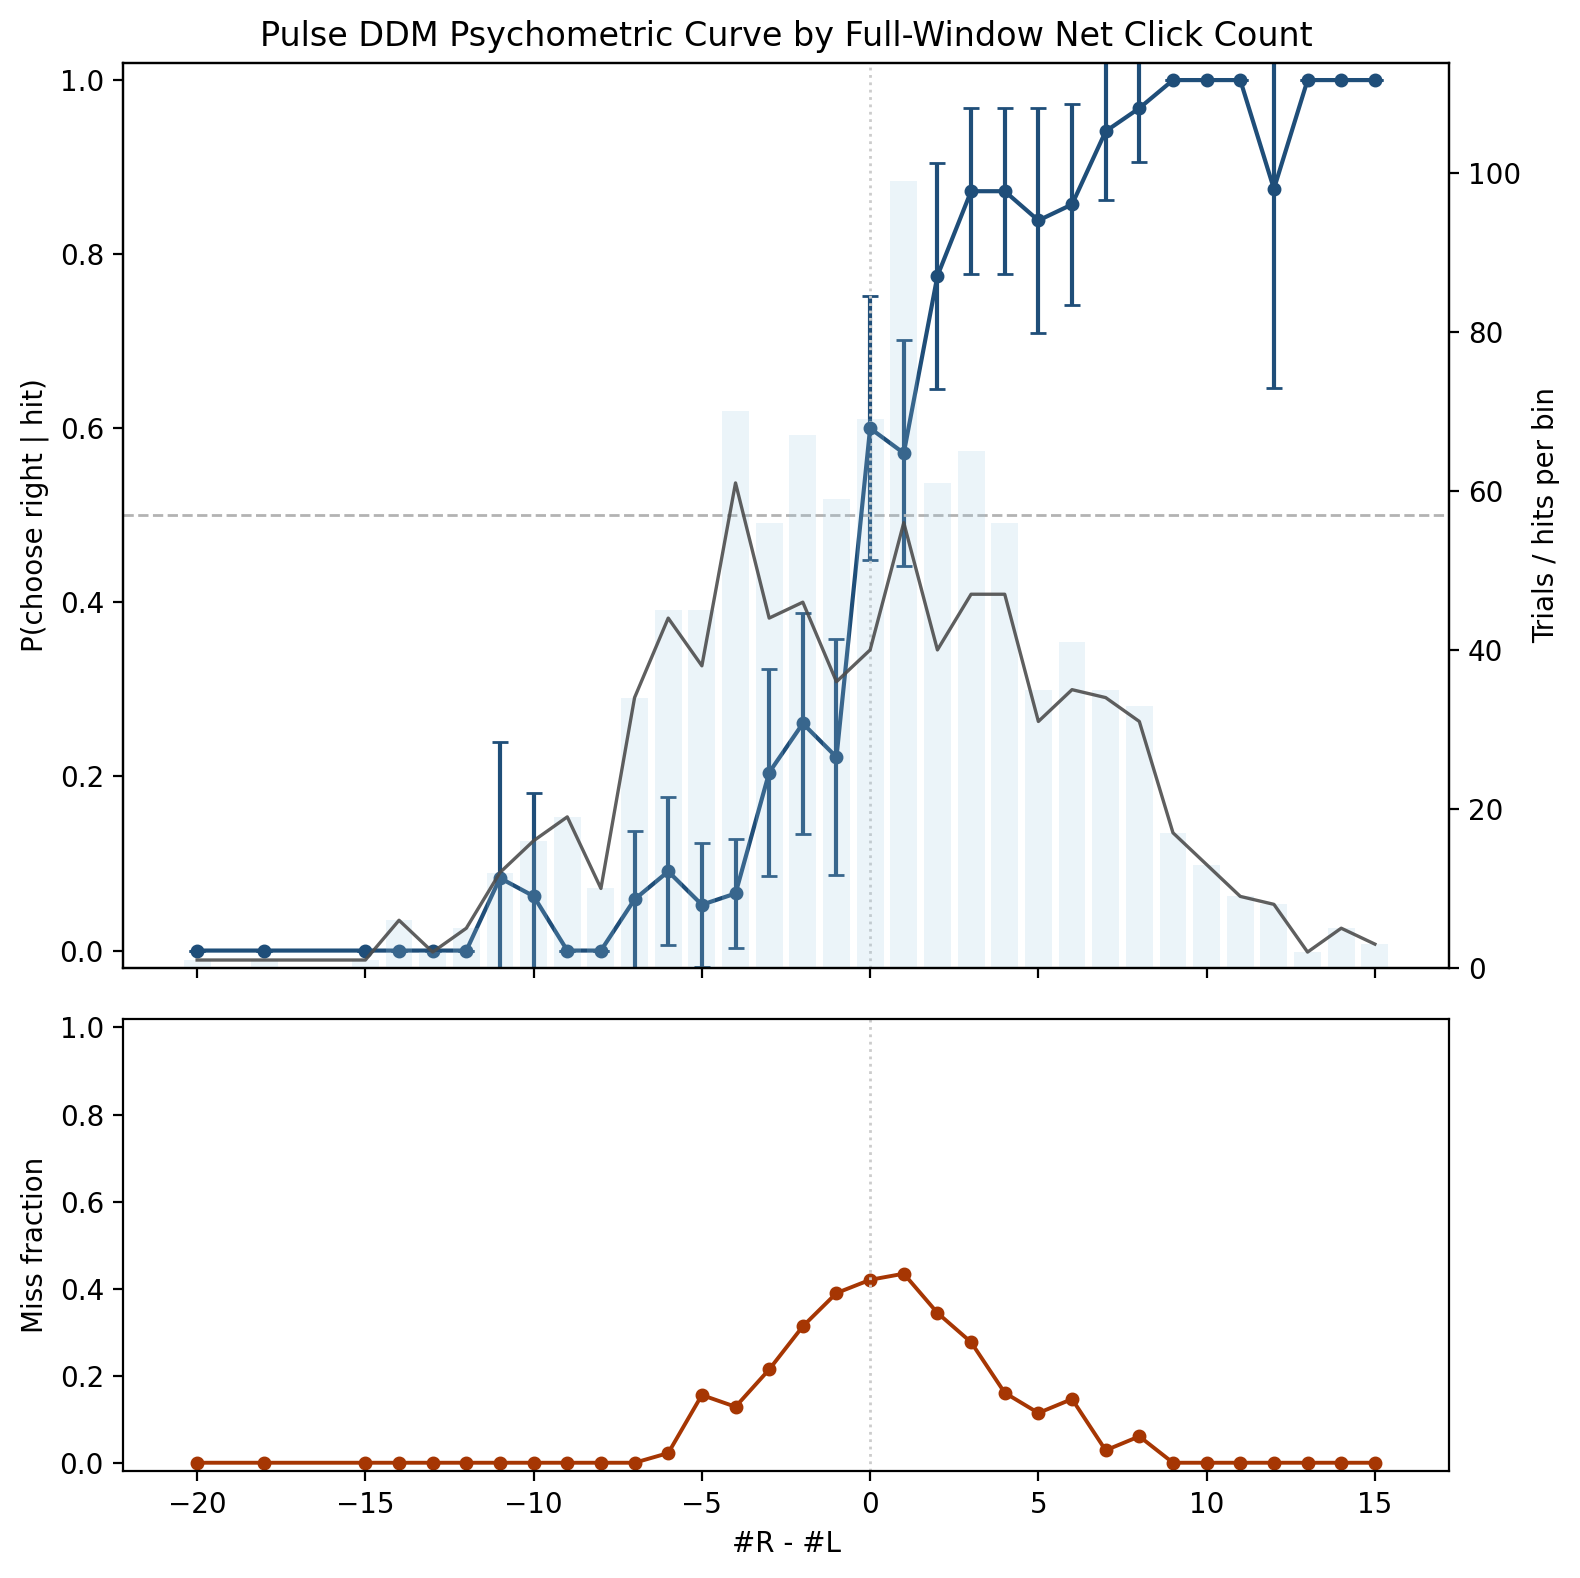

Condition summary
{'condition': 'right_biased', 'seed': 2663447816, 'lambda_click_L': 0.03, 'lambda_click_R': 0.03, 'num_trials': 500, 'hit_fraction': 0.794, 'p_right': 0.4836272040302267}
{'condition': 'left_biased', 'seed': 1568669181, 'lambda_click_L': 0.03, 'lambda_click_R': 0.03, 'num_trials': 500, 'hit_fraction': 0.794, 'p_right': 0.48866498740554154}

Net-click range
-20 to 15

Central bins
{'net_click_count': -5, 'num_trials': 45, 'num_hit': 38, 'miss_fraction': 0.15555555555555556, 'p_right': 0.05263157894736842, 'ci_half_width': np.float64(0.07099813237678437)}
{'net_click_count': -4, 'num_trials': 70, 'num_hit': 61, 'miss_fraction': 0.12857142857142856, 'p_right': 0.06557377049180328, 'ci_half_width': np.float64(0.062119613127866506)}
{'net_click_count': -3, 'num_trials': 56, 'num_hit': 44, 'miss_fraction': 0.2142857142857143, 'p_right': 0.20454545454545456, 'ci_half_width': np.float64(0.11918794545211743)}
{'net_click_count': -2, 'num_trials': 67, 'num_hit': 46, 'miss_fract

In [8]:
# Editable parameters
LAMBDA_RIGHT = 0.03
LAMBDA_LEFT = 0.03
NOISE_SCALE = 0.3
LAMBDA_COMMIT = 2.0
DELTA_CLICK_X = 0.1

DT_DDM = 10.0
T_START = 10
DUR = 500
X0 = 0.5
BOUNDARY = 1.0

NUM_TRIALS_PER_CONDITION = 500
SEED = 201

conditions, condition_rows, summary_rows = run_experiment()
fig, _ = plot_summary(summary_rows)
plt.show()

print('Condition summary')
for row in condition_rows:
    print(row)

print('\nNet-click range')
print(int(summary_rows[0]['net_click_count']), 'to', int(summary_rows[-1]['net_click_count']))

print('\nCentral bins')
for row in summary_rows:
    value = int(row['net_click_count'])
    if -5 <= value <= 5:
        print(row)


In [ ]:
if SAVE_OUTPUTS:
    run_dir = save_outputs(
        conditions=conditions,
        condition_rows=condition_rows,
        summary_rows=summary_rows,
        figure=fig,
    )
    print(f'Saved outputs to {run_dir}')
else:
    print('SAVE_OUTPUTS is False; nothing written to disk.')
